<p align="center">
  <img src="img/logoitqv1.png" width="270" style="margin-right: 20px;">
</p>
<div style="clear:both;"></div>

# Programa15.Clasificacion.LOGR

## 0.1 PAO25-25- REGRESIÓN LOGÍSTICA
<br>

<img src="img/python_logo.png" width="300">
<br>

*Elvis David Pachacama* 

*Ian Mijail Morales Patiño*


<br>
<a href="https://github.com/Ian-183/practica-machine-learning">https://github.com/Ian-183/practica-machine-learningb</a>

In [7]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import sklearn.metrics as metrics
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, cross_val_score, train_test_split, KFold
from sklearn import preprocessing
from evaluacion_funciones import *


In [8]:
# Carga de datos.
datos = load_iris()
X = datos.data[:, 2:]  # Utilizamos solo 2 atributos.
y = datos.target
print(np.shape(X))

(150, 2)


In [9]:
# Métricas de evaluación.
metricas = {
    'ACC': metrics.accuracy_score,
    'PREC': lambda y_true, y_pred:
    metrics.precision_score(y_true, y_pred, average='micro'),
    'RECALL': lambda y_true, y_pred:
    metrics.recall_score(y_true, y_pred, average='micro'),
    'F1': lambda y_true, y_pred:
    metrics.f1_score(y_true, y_pred, average='micro')}

In [10]:
# 1) Partición de datos externa
X_training, X_testing, y_training, y_testing = train_test_split(X, y, test_size=0.2, random_state=42)
print(np.shape(X_training))

(120, 2)


# ------------- TRAINING ---------------- #

In [11]:
# 2) Extracción de características

In [12]:
# 3) Estandarización de los datos de entrenamiento
standardizer = preprocessing.StandardScaler()
X_stdr = standardizer.fit_transform(X_training)
# print(X_stdr)

In [13]:
# 4) Selección de atributos

In [18]:
# 5) Construcción del algoritmo de aprendizaje.
algoritmos = {'LOGR': LogisticRegression(penalty='l1', l1_ratio=1.0, solver='saga', max_iter=1000, random_state=42)}

In [19]:
# 5.1) Validación cruzada interna y Optimización de los hiperparámetros
y_pred = {}
for nombre, alg in algoritmos.items():
    y_pred[nombre] = cross_val_predict(alg, X_stdr, y_training,
                                       cv=KFold(n_splits=10, shuffle=True, random_state=42))
    results = evaluacion(y_training, y_pred[nombre], metricas)
    print(metrics.confusion_matrix(y_training, y_pred[nombre]))
    print(results)
# results = cross_val_score(alg, X_stdr, y_training, cv = KFold(n_splits=10, shuffle=True, random_state=42))
# print("Accuracy: %0.4f +/- %0.4f" % (results.mean(), results.std()))

[[40  0  0]
 [ 0 38  3]
 [ 0  4 35]]
{'ACC': 0.9416666666666667, 'PREC': 0.9416666666666667, 'RECALL': 0.9416666666666667, 'F1': 0.9416666666666667}


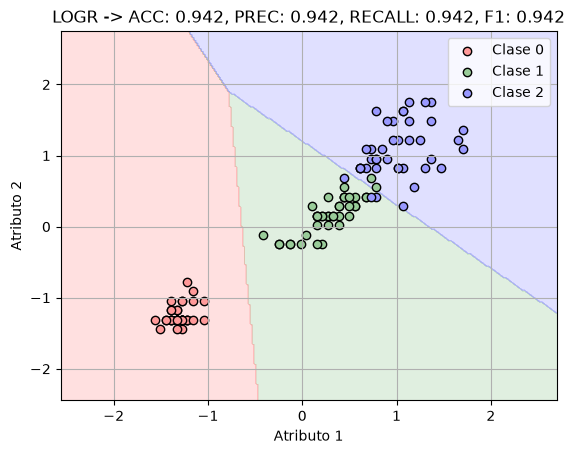

In [20]:
# 5.2) Entrenamiento del modelo definitivo
model = algoritmos['LOGR'].fit(X_stdr, y_training)
# Visualización de las fronteras de decisión
mapa_modelo_clasif_2d(X_stdr, y_training, model, results, nombre)

# ------------- PREDICTION ---------------- #

In [21]:
# 6) Extracción de las características de test

In [22]:
# 7) Estandarización de las característiacs de test
X_test_stdr = standardizer.transform(X_testing)

In [23]:
# 8) Selección de los atributos de test

In [24]:
# 9) Predicción del conjunto de test
y_pred_test = model.predict(X_test_stdr)
print(y_pred_test)

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [25]:
# 10) Evaluación del modelo sobre el conjunto de test
results = evaluacion(y_testing, y_pred_test, metricas)
print(results)
print(metrics.confusion_matrix(y_testing, y_pred_test))

{'ACC': 1.0, 'PREC': 1.0, 'RECALL': 1.0, 'F1': 1.0}
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


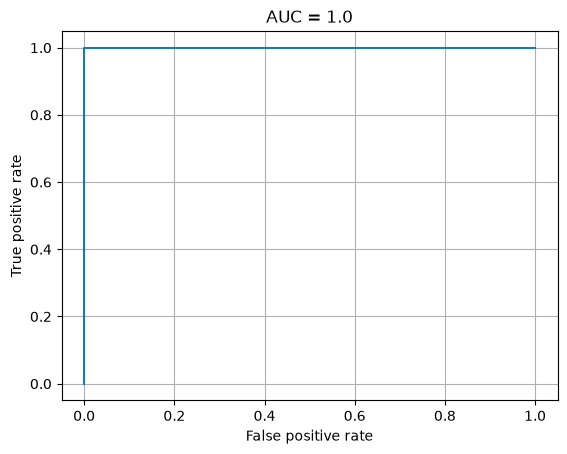

In [26]:
# Ploteamos la curva ROC
y_proba_test = model.predict_proba(X_test_stdr)  # "predict_proba" para extraer probabilidades vez de predicciones
y_test_bin = preprocessing.label_binarize(y_testing, classes=[0, 1, 2])  # Usar "label_binarize" en el caso de problemas multiclase
auc = metrics.roc_auc_score(y_testing, y_proba_test, multi_class='ovr')  # Area Under the ROC curve (AUC)
fpr, tpr, th = metrics.roc_curve(y_test_bin[:, 1], y_proba_test[:, 1])
plt.plot(fpr, tpr)
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('AUC = ' + str(np.round(auc, 4)))
plt.grid()
plt.show()